# TASK 4 - Email Spam Detection with Machine Learning

## Objective

The objective of this project is to build a Natural Language Processing (NLP) based binary classification model to distinguish spam messages from legitimate (ham) messages.

The project includes text preprocessing, TF-IDF feature extraction, model training, evaluation, and comparison of classification models.

# Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

The SMS Spam Collection dataset is loaded into a pandas DataFrame.
The dataset contains the message category and the corresponding message text.

In [6]:
df = pd.read_csv(
    "dataset/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (5572, 2)

Column Names:
['label', 'message']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

# Class Distribution

The dataset contains two classes: ham and spam.

The class distribution is checked using both the number of messages and their percentage. This helps to understand whether the dataset is balanced or imbalanced.

The dataset contains more ham messages than spam messages, indicating that the classes are imbalanced.

In [12]:
class_percentage = df["label"].value_counts(normalize=True) * 100

print("Class Counts:")
print(df["label"].value_counts())

print("\nClass Percentage:")
print(class_percentage)

Class Counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


# Bar Chart

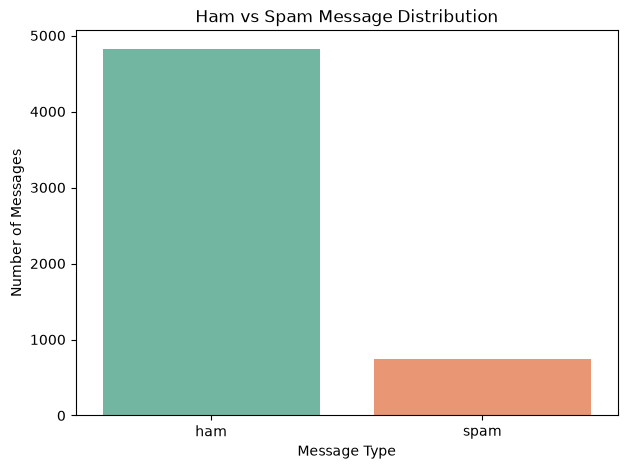

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label", hue="label", palette="Set2", legend=False)

plt.title("Ham vs Spam Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

# Class Percentage

The percentage distribution shows that ham messages form the majority of the dataset, while spam messages represent a smaller portion.

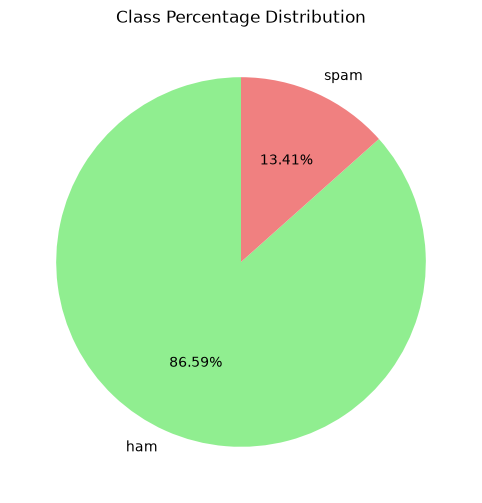

In [14]:
class_percentage = df["label"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))

plt.pie(
    class_percentage,
    labels=class_percentage.index,
    autopct="%.2f%%",
    startangle=90,
    colors=["lightgreen", "lightcoral"]
)

plt.title("Class Percentage Distribution")

plt.show()

# Text Preprocessing

Text preprocessing is performed to clean the email messages before converting them into numerical features.

The following preprocessing steps are applied:

1. Convert text to lowercase.
2. Remove punctuation and special characters.
3. Remove stopwords.
4. Apply stemming to reduce words to their root form.

In [16]:
%pip install nltk

  Using cached nltk-3.10.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached regex-2026.7.19-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.10.2-py3-none-any.whl (1.7 MB)
Using cached regex-2026.7.19-cp312-cp312-win_amd64.whl (277 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [18]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ELCOT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Text Cleaning Function

A preprocessing function is created to clean each message consistently.

The function converts text to lowercase, removes punctuation and numbers, removes stopwords, and applies stemming.

In [19]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    
    return " ".join(words)

In [20]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl 3 week word back id like fun ...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea 900...
9,Had your mobile 11 months or more? U R entitle...,mobil 11 month u r entitl updat latest colour ...


# TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the cleaned text messages into numerical features that machine learning models can understand.

TF-IDF gives higher importance to words that are frequent in a particular message but less common across the complete dataset.

In this project, the cleaned messages are converted into TF-IDF vectors before training the classification models.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer

A TF-IDF Vectorizer is created to transform the cleaned email/message text into numerical feature vectors.

The maximum number of features is limited to 5000 to keep the feature space manageable.

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_message"])

In [23]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (5572, 5000)


# Encode Target Labels

The target column contains two classes: ham and spam. These labels are converted into numerical values so that they can be used by the machine learning classifiers.

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["label"])

print("Encoded Labels:", y[:10])

Encoded Labels: [0 0 1 0 0 1 0 0 1 1]


# Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of the machine learning models on unseen data.

80% of the data is used for training and 20% is used for testing.

The same random state is used to ensure reproducible results.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4457, 5000)
X_test : (1115, 5000)
y_train: (4457,)
y_test : (1115,)


# Train-Test Split for Text Data

The cleaned messages are divided into training and testing sets before applying TF-IDF.

80% of the messages are used for training and 20% are used for testing.

Splitting the text before TF-IDF helps prevent information from the test set from being used during feature extraction.

In [27]:
X_text_train, X_text_test, y_train, y_test = train_test_split(
    df["clean_message"],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency. It is a text feature extraction technique that converts text messages into numerical values that machine learning algorithms can understand.

TF-IDF measures how important a word is in a particular message compared with how frequently that word appears across all messages.

- **Term Frequency (TF):** Measures how frequently a word appears in a particular message.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that occur in many messages and gives more importance to words that are less common across the dataset.
- **TF-IDF Score:** Combines TF and IDF to assign a numerical importance score to each word.

For example, common words that appear in many messages receive lower importance, while words that are more specific to certain messages receive higher importance.

The TF-IDF vectorizer is fitted only on the training messages and then used to transform both the training and testing messages. This prevents data leakage from the test set.

In [28]:
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_text_train)

X_test = tfidf.transform(X_text_test)

In [29]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4457, 5000)
X_test : (1115, 5000)
y_train: (4457,)
y_test : (1115,)


# Classifier 1: Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic machine learning algorithm that is commonly used for text classification tasks.

It is suitable for spam detection because it works effectively with numerical text features such as TF-IDF values.

The model learns the relationship between the TF-IDF features and the target classes, ham and spam. It is then used to classify unseen messages from the testing dataset.

# Import Multinomial Naive Bayes

In [30]:
from sklearn.naive_bayes import MultinomialNB

# Create Model

In [31]:
naivebayes_model = MultinomialNB()

# Train Model

In [32]:
naivebayes_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[0. ,0. ,0. ,...,0.42,0.17,1.47], [0.28,0.53,0.35,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-9.57,-9.57,-9.57,...,-9.22,-9.41,-8.67], [-8.62,-8.45,-8.57,...,-8.87,-8.87,-8.87]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


# Predict Test Messages

The trained Multinomial Naive Bayes model is used to predict the class of messages in the testing dataset.

In [33]:
naivebayes_pred = naivebayes_model.predict(X_test)

# Evaluation of Multinomial Naive Bayes

The performance of the Multinomial Naive Bayes classifier is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

These metrics help us understand how well the model distinguishes between ham and spam messages.

- **Accuracy:** Measures the overall percentage of correctly classified messages.
- **Precision:** Measures how many messages predicted as spam are actually spam.
- **Recall:** Measures how many actual spam messages are correctly detected.
- **F1-score:** Provides a balance between precision and recall.
- **Confusion Matrix:** Shows the number of correct and incorrect predictions for each class.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, naivebayes_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, naivebayes_pred, target_names=["ham", "spam"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, naivebayes_pred))

Accuracy: 0.9668161434977578

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Confusion Matrix:
[[966   0]
 [ 37 112]]


# Confusion Matrix Visualization

The confusion matrix is visualized using a heatmap to make the correct and incorrect predictions for ham and spam classes easier to understand.

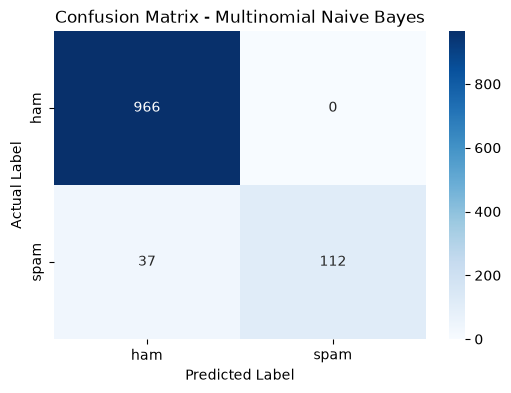

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, naivebayes_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

# Why is Recall Important for Spam Detection

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the model.

A high spam recall means that the model can detect most of the spam messages and prevent them from being classified as legitimate messages.

In this model, the spam recall is 0.75, which means that the model correctly identifies 75% of the actual spam messages. However, some spam messages are still classified as ham.

Therefore, improving spam recall is important for reducing missed spam messages.

# Logistic Regression

Logistic Regression is a supervised machine learning classification algorithm used to classify messages into two categories: ham and spam.

For this task, Logistic Regression is trained using the TF-IDF features extracted from the SMS messages.

The model learns the relationship between the numerical TF-IDF features and the target labels. After training, it is used to predict whether unseen test messages are ham or spam.

Logistic Regression is used as the second classifier to compare its performance with Multinomial Naive Bayes.

# Import Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

# Create Model

In [37]:
logistic_model = LogisticRegression(max_iter=1000)

# Train Logistic Regression Model

A Logistic Regression classifier is created with a higher maximum number of iterations to allow the model to converge properly on the TF-IDF feature matrix.

In [38]:
logistic_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Model Training

The Logistic Regression model is trained using the training TF-IDF features and their corresponding target labels.

# Predict Test Messages

The trained Logistic Regression model is used to predict whether the messages in the test dataset are ham or spam.

In [39]:
logistic_pred = logistic_model.predict(X_test)

# Evaluation of Logistic Regression

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
logistic_accuracy = accuracy_score(y_test, logistic_pred)
print("Accuracy:", logistic_accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["ham", "spam"]
    )
)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

Accuracy: 0.968609865470852

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
[[966   0]
 [ 35 114]]


# Confusion Matrix - Logistic Regression

The confusion matrix shows the number of correctly and incorrectly classified ham and spam messages.

It helps identify false positives and false negatives and provides a better understanding of the model's classification performance.

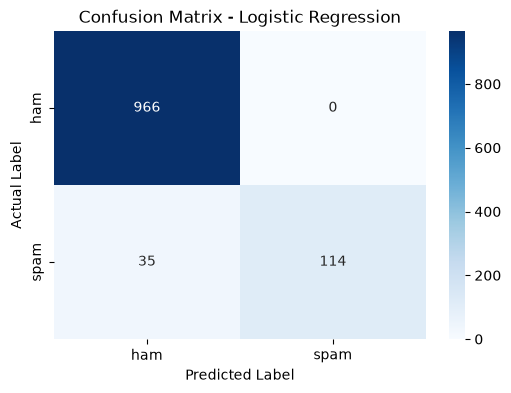

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, logistic_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Why Recall is Important for Spam Detection

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the model.

A low spam recall means that some spam messages are incorrectly classified as legitimate ham messages. These false negatives are undesirable because unwanted or potentially harmful spam emails may reach the user's inbox.

Therefore, while accuracy is important, spam recall should also be considered when selecting the best model.

The Logistic Regression model achieved a spam recall of 0.77. This means that the model correctly identified approximately 77% of the actual spam messages in the test set.

The remaining spam messages were classified as ham, resulting in 35 false negatives. Therefore, spam recall is an important metric for evaluating this model.

# SVM Classifier

Support Vector Machine (SVM) is a supervised machine learning algorithm that can be used for binary classification.

For text classification, SVM works effectively with high-dimensional features such as TF-IDF vectors. The model learns a decision boundary that separates spam messages from legitimate ham messages.

In this task, the SVM classifier is trained using the TF-IDF features extracted from the training messages.

# Import Linear SVM Classifier

In [42]:
from sklearn.svm import LinearSVC

# Create Model

In [43]:
svm_model = LinearSVC()

# Train SVM Model

The Linear Support Vector Classifier is used to classify messages into ham and spam categories.

The model is trained using the TF-IDF representation of the training messages.

In [44]:
svm_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

# Predict Test Messages - SVM

The trained SVM model is used to predict the classes of messages in the testing dataset.

In [45]:
svm_pred = svm_model.predict(X_test)

# Evaluation of SVM

The SVM model is evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

These metrics help measure how effectively the model distinguishes between ham and spam messages.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
svm_accuracy = accuracy_score(y_test, svm_pred)
print("Accuracy:", svm_accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["ham", "spam"]
    )
)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Accuracy: 0.9847533632286996

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
[[965   1]
 [ 16 133]]


# Confusion Matrix - SVM

The confusion matrix shows the correctly and incorrectly classified ham and spam messages by the SVM model.

It helps identify false positives and false negatives and provides a detailed view of the model's classification performance.

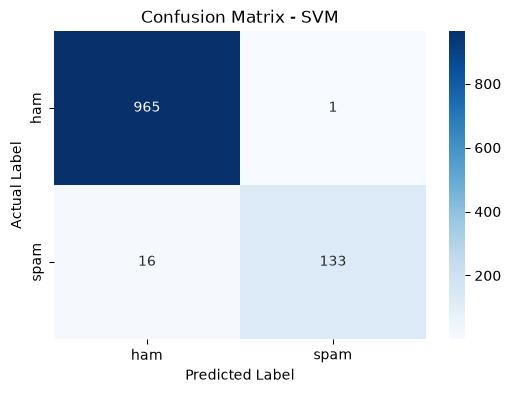

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM")
plt.show()

# Why Recall is Important for Spam Detection

Recall measures how many of the actual spam messages are correctly identified as spam.

In spam detection, recall is particularly important because a low recall means that some spam messages are incorrectly classified as legitimate ham messages.

These missed spam messages are called false negatives. A high spam recall helps the system detect a larger proportion of actual spam messages and reduces the number of spam messages that reach the user's inbox.

Therefore, recall is an important metric for evaluating a spam detection model, along with precision, F1-score, and accuracy.

The SVM model achieved a spam recall of 0.89. This means that the model correctly identified approximately 89% of the actual spam messages in the test set.

The confusion matrix shows that 16 spam messages were incorrectly classified as ham. These are false negatives and explain why the spam recall is below 1.00.

# Model Comparison

Three machine learning classifiers were trained and evaluated for email spam detection:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Support Vector Machine (SVM)

The models are compared using accuracy, precision, recall, and F1-score.

For spam detection, recall is especially important because a low spam recall means that some spam messages are incorrectly classified as legitimate messages.

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
comparison = []
# Multinomial Naive Bayes
comparison.append([
    "Multinomial Naive Bayes",
    accuracy_score(y_test, naivebayes_pred),
    precision_score(y_test, naivebayes_pred),
    recall_score(y_test, naivebayes_pred),
    f1_score(y_test, naivebayes_pred)
])

# Logistic Regression
comparison.append([
    "Logistic Regression",
    accuracy_score(y_test, logistic_pred),
    precision_score(y_test, logistic_pred),
    recall_score(y_test, logistic_pred),
    f1_score(y_test, logistic_pred)
])

# SVM
comparison.append([
    "Support Vector Machine",
    accuracy_score(y_test, svm_pred),
    precision_score(y_test, svm_pred),
    recall_score(y_test, svm_pred),
    f1_score(y_test, svm_pred)
])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.966816,1.000000,0.751678,0.858238
1,Logistic Regression,0.968610,1.000000,0.765101,0.866920
2,Support Vector Machine,0.984753,0.992537,0.892617,0.939929


# Best Performing Model

The models are compared based on their evaluation metrics. Since this project focuses on spam detection, recall and F1-score are given particular importance along with overall accuracy.

A model with high spam recall is preferred because it reduces the number of spam messages that are incorrectly classified as legitimate emails.

In [50]:
best_model = comparison_df.loc[
    comparison_df["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Support Vector Machine
Accuracy                   0.984753
Precision                  0.992537
Recall                     0.892617
F1-Score                   0.939929
Name: 2, dtype: object


# Model Performance Comparison

The following chart compares the performance of the three classifiers based on accuracy, precision, recall, and F1-score.

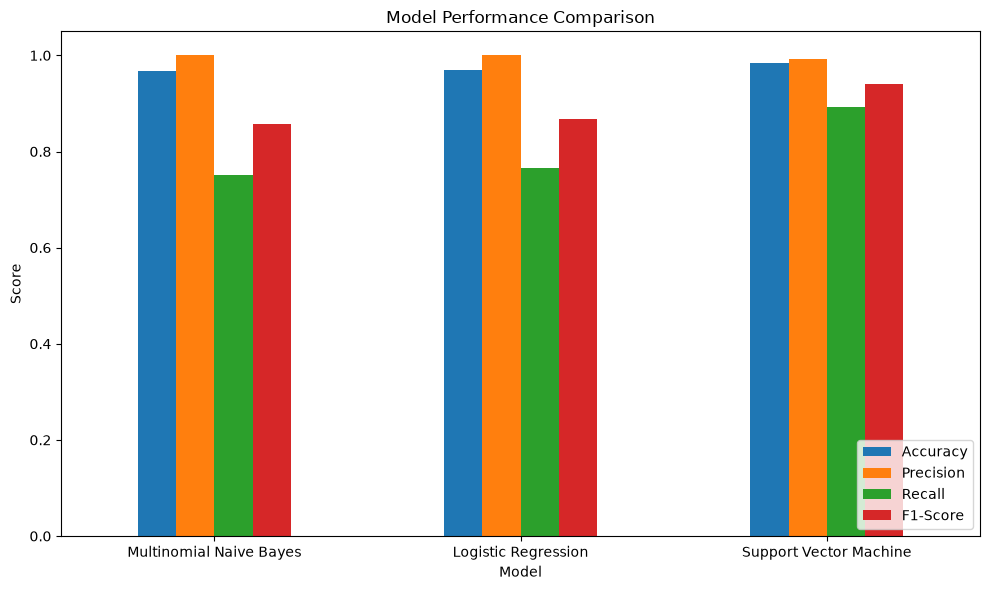

In [51]:
import matplotlib.pyplot as plt
comparison_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Save the Best Model

Based on the evaluation results, the Support Vector Machine (SVM) model achieved the highest accuracy and the best spam recall among the trained classifiers.

Therefore, the SVM model is selected as the best-performing model.

The trained SVM model and TF-IDF vectorizer are saved so that they can be reused later for predicting new email messages without retraining the model.

In [52]:
import joblib
import os
os.makedirs("model", exist_ok=True)
joblib.dump(svm_model, "model/svm_model.pkl")
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")
print("Best model and TF-IDF vectorizer saved successfully.")

Best model and TF-IDF vectorizer saved successfully.


In [53]:
print(os.listdir("model"))

['svm_model.pkl', 'tfidf_vectorizer.pkl']


# Verify Saved Model

The saved SVM model and TF-IDF vectorizer are loaded again to verify that the saved files can be reused successfully.

In [54]:
loaded_svm_model = joblib.load("model/svm_model.pkl")
loaded_tfidf = joblib.load("model/tfidf_vectorizer.pkl")

print("SVM model loaded successfully.")
print("TF-IDF vectorizer loaded successfully.")

SVM model loaded successfully.
TF-IDF vectorizer loaded successfully.


# WordCloud Visualization

WordCloud is used to visualize the most frequently occurring words in the dataset.

Separate word clouds are created for:
- Ham messages
- Spam messages

Words that occur more frequently are displayed with larger font sizes. This provides a simple visual understanding of the common words used in legitimate and spam messages.

In [55]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separating Ham and Spam Messages

The messages are separated into two groups based on their labels so that the common words in ham and spam messages can be visualized independently.

In [57]:
ham_text = " ".join(df[df["label"] == "ham"]["clean_message"])
spam_text = " ".join(df[df["label"] == "spam"]["clean_message"])

# WordCloud of Ham Messages

The following word cloud shows the frequently occurring words in legitimate (ham) messages.

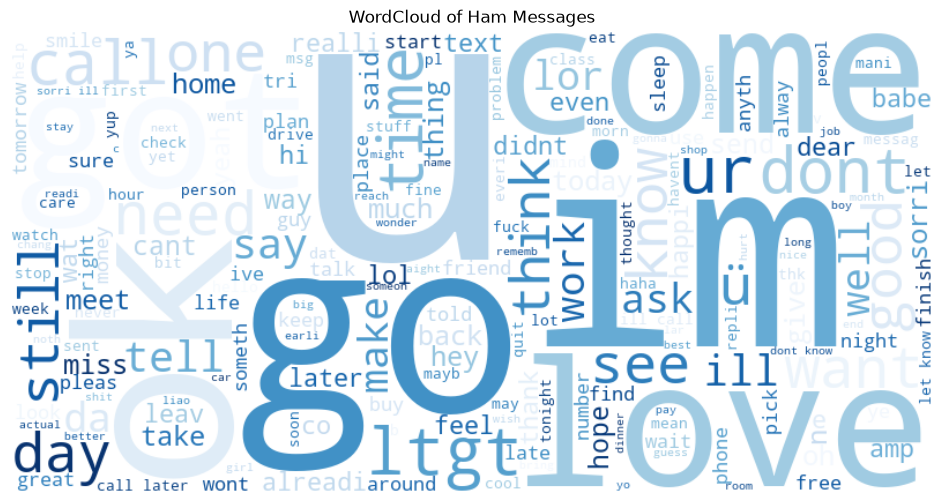

In [58]:
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Blues"
).generate(ham_text)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Ham Messages")
plt.show()

# WordCloud of Spam Messages

The following word cloud shows the frequently occurring words in spam messages. These words can provide useful insights into the common language and promotional patterns found in spam messages.

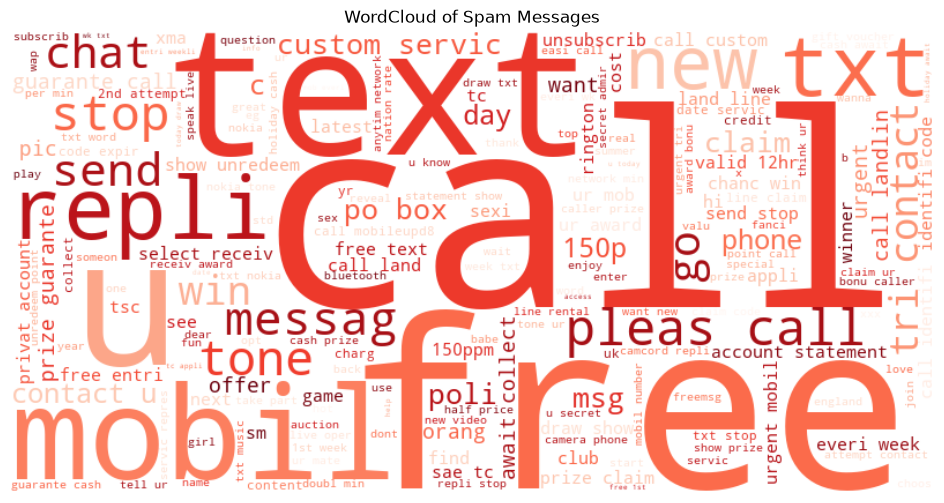

In [59]:
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Spam Messages")
plt.show()

The ham word cloud contains commonly used words from normal personal and conversational messages.

The spam word cloud contains words that are more frequently associated with promotional offers, prizes, rewards, financial messages, and other unsolicited content.

The word clouds provide a visual representation of the differences in vocabulary between ham and spam messages. However, the word clouds are used only for visualization and are not directly used for model training or evaluation.

# Conclusion

This project developed a machine learning based email spam detection system using Natural Language Processing (NLP) techniques.

The SMS Spam Collection dataset was used to classify messages into two categories: ham (legitimate messages) and spam. The text data was cleaned using lowercase conversion, punctuation removal, stopword removal, and stemming.

TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert the cleaned text messages into numerical features suitable for machine learning models.

Three classification algorithms were trained and evaluated:

- Multinomial Naive Bayes
- Logistic Regression
- Support Vector Machine (SVM)

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

Among the evaluated models, SVM achieved the best overall performance, with an accuracy of approximately 98.48% and a spam recall of approximately 89%.

Recall is particularly important in spam detection because it measures how many actual spam messages are correctly identified. A higher spam recall helps reduce the number of spam messages that are incorrectly classified as legitimate messages.

WordCloud visualizations were also created to identify frequently occurring words in spam and ham messages.

Overall, the project demonstrates how NLP and machine learning can be combined to build an effective email spam detection system.